# Unsupervised Learning: DBSCAN (Density-Based Spatial Clustering)
**Developer:** Iris Li  

### 1. Why DBSCAN?
Unlike K-Means, which requires us to guess the number of clusters ($k$), **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) finds clusters based on how "crowded" the data points are. 

**Key Advantages:**
* **No 'k' Required:** It discovers the number of clusters automatically.
* **Outlier Detection:** It identifies "noise" points—countries that don't fit into any standard category. In our emissions data, these are our most critical outliers (the "Super-Polluters").

### 2. The Core Parameters
DBSCAN relies on two critical settings:
1. **$\epsilon$ (Epsilon):** The maximum distance between two points to be considered neighbors.
2. **MinSamples:** The minimum number of points required to form a "dense" region (a cluster).

Points that do not meet these density requirements are labeled **-1 (Outliers/Noise).**

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from my_ml_package.unsupervised.dbscan import DBSCAN
sys.path.append(os.path.abspath('../../../src'))

# 1. Load & Scale (Crucial: DBSCAN is extremely sensitive to distance)
#df = pd.read_csv('../data/emissions.csv')
df = pd.read_csv('../../../data/emissions.csv')
latest_year = df['year'].max()
df_recent = df[df['year'] == latest_year].dropna(subset=['total_ghg', 'ghg_per_capita'])

X = df_recent[['total_ghg', 'ghg_per_capita']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Initialize and Fit
# We use eps=0.5 as a starting point for standardized data
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

print("Unique clusters found:", np.unique(clusters))
print(f"Number of outliers (-1) identified: {list(clusters).count(-1)}")

Unique clusters found: [-1  0  1]
Number of outliers (-1) identified: 12


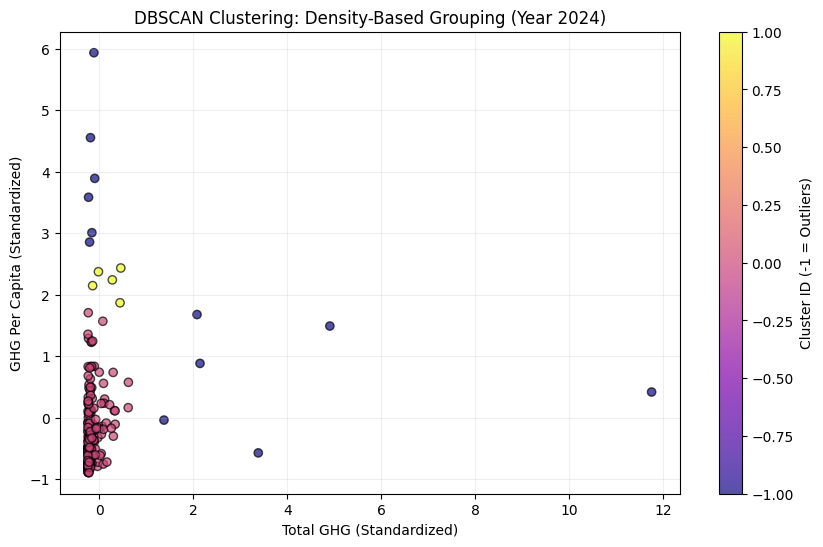

In [2]:
plt.figure(figsize=(10, 6))

# Plot the clusters
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap='plasma', edgecolors='k', alpha=0.7)

plt.title(f"DBSCAN Clustering: Density-Based Grouping (Year {latest_year})")
plt.xlabel("Total GHG (Standardized)")
plt.ylabel("GHG Per Capita (Standardized)")
plt.colorbar(scatter, label="Cluster ID (-1 = Outliers)")
plt.grid(True, alpha=0.2)
plt.show()

### 4. Interpretation of Density Results
The DBSCAN visualization (Year 2024) provides a stark contrast to our previous K-Means results:

* **High Global Homogeneity:** Most nations belong to a single dense cluster (Cluster 0), indicating that the baseline for global emissions is relatively consistent across most developing and mid-tier nations.
* **Feature Sensitivity:** By using standardized data, we can see that "outlier-ness" in this dataset is driven primarily by **Total GHG volume** (the points drifting far right) rather than just per-capita intensity.
* **The Value of Noise (-1):** DBSCAN successfully isolated the world's largest emitters as "Noise." This is mathematically significant because it proves that these countries are so unique in their impact that they cannot be grouped with the rest of the global community.

In [3]:
# Create a mask for the outliers
outlier_mask = (clusters == -1)

# Get the names of the outlier countries
outlier_countries = df_recent[outlier_mask]['country'].unique()

print(f"Total Outliers Found: {len(outlier_countries)}")
print("-" * 30)
print(outlier_countries)

Total Outliers Found: 12
------------------------------
['Bahrain' 'Brazil' 'Brunei' 'China' 'India' 'Indonesia' 'Kuwait'
 'Mongolia' 'Qatar' 'Russia' 'Trinidad and Tobago' 'United States']


### 5. Final Analysis: Who are the Outliers?

Our DBSCAN model identified 12 nations as "Noise" (Cluster -1). These countries represent the most significant challenges to global climate policy because they do not follow the standard patterns of the other 180+ nations.

#### **Categories of Outliers:**
1. **The Heavyweights:** Nations like **China, the USA, and India** are outliers due to the sheer volume of their industrial output. No other nations currently operate at this scale.
2. **The High-Intensity Producers:** Nations like **Qatar, Kuwait, and Brunei** are outliers due to extremely high per-capita footprints, often tied to oil and gas production or high-wealth lifestyles.
3. **The Transitional Outliers:** Nations like **Brazil and Indonesia** represent unique profiles where high land-use emissions (forestry/agriculture) combined with growing industry push them out of the "standard" developing nation density.

**Architectural Takeaway:** These 12 countries are where the "real" work of climate change mitigation happens. While the rest of the world (Cluster 0) follows a predictable trend, these outliers require specialized, bespoke policy interventions.